In [95]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [96]:
#load the data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [97]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [98]:
#understand target variable
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [99]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Most customers do not churn.

Churn is imbalanced, so accuracy alone wouldn’t be a reliable metric if we later build a model.

In [100]:
#Fix total charges column
#Total amount of money a customer has spent on the company's services.
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [101]:
#convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") #coerce will convert non-numeric values to NaN

In [102]:
#check for missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

There are 11 missing values in TotalCharges.

In [103]:
#print the customers with null total charges
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


The customers with null total charges are those who have just joined and have not been billed yet. We can fill these missing values with 0 since they have not spent anything yet.

In [104]:
#fill missing values with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
#check for missing values again
df["TotalCharges"].isnull().sum()

np.int64(0)

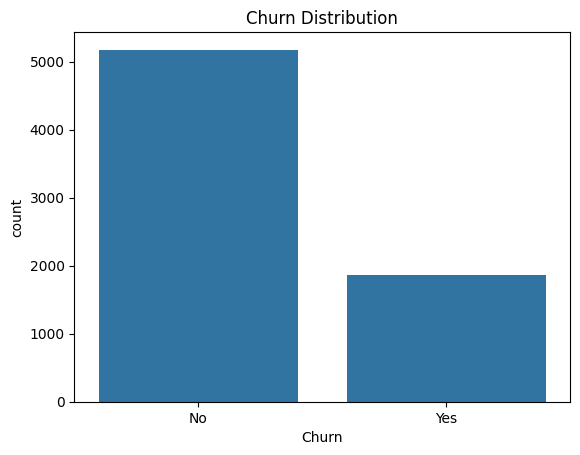

In [105]:
#Begin Exploratory Data Analysis (EDA)
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

The dataset is imbalanced, with significantly more customers retained than churned, indicating churn is a relatively infrequent event.

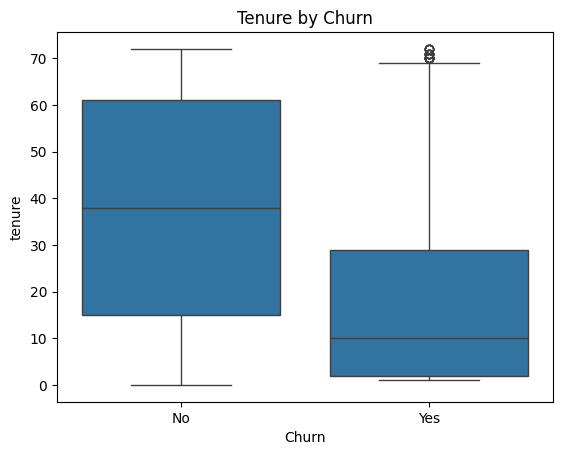

In [106]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.show()

Customers who churn tend to have significantly lower tenure, suggesting that churn risk is highest early in the customer lifecycle.

The company should focus on retaining new customers, especially in the first few months.

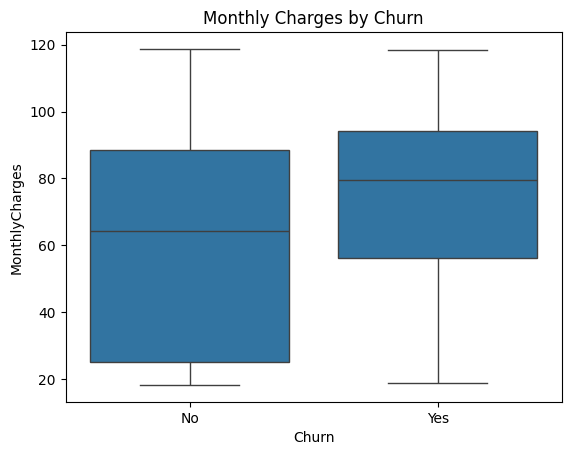

In [107]:
#Monthly charges vs churn
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

Customers with higher monthly charges show a greater tendency to churn, indicating price sensitivity may be a key driver.

Consider pricing strategies or discounts for high-paying customers at risk.

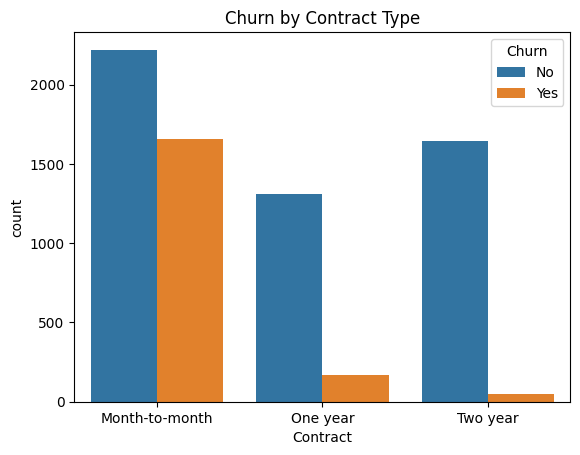

In [108]:
#Contract type vs churn
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

Customers on month-to-month contracts exhibit significantly higher churn rates compared to those on longer-term contracts.

Encourage customers to switch to long-term contracts to reduce churn.

Key Insights

- Churn is relatively low but imbalanced
- New customers are most likely to churn
- Higher monthly charges increase churn risk
- Month-to-month contracts have the highest churn rates

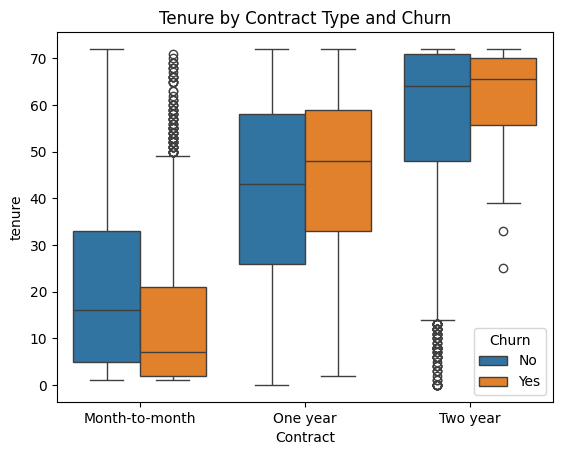

In [109]:
#Contract + Tenure + Churn
sns.boxplot(data=df, x="Contract", y="tenure", hue="Churn")
plt.title("Tenure by Contract Type and Churn")
plt.show()

Churn is heavily concentrated among low-tenure customers on month-to-month contracts, while long-term contracts are associated with both higher tenure and lower churn.

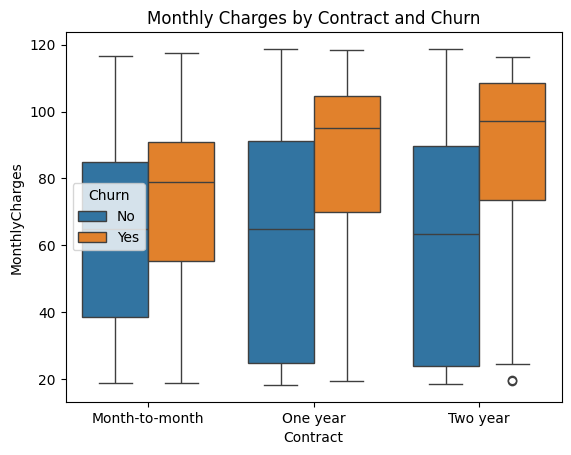

In [110]:
#Monthly Charges + Contract + Churn
sns.boxplot(data=df, x="Contract", y="MonthlyCharges", hue="Churn")
plt.title("Monthly Charges by Contract and Churn")
plt.show()

High monthly charges combined with month-to-month contracts are strongly associated with increased churn risk.

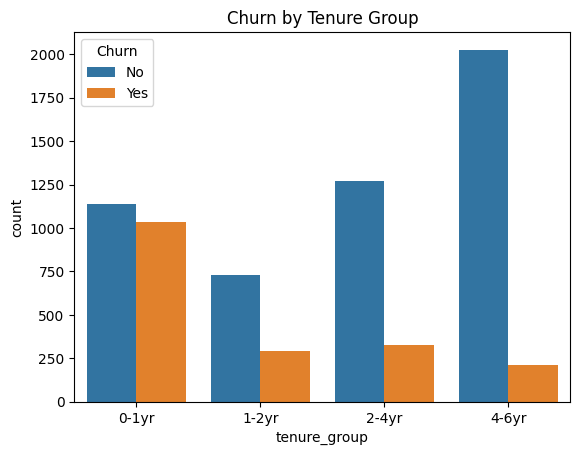

In [111]:
#Tenure Groups
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"]
)

sns.countplot(data=df, x="tenure_group", hue="Churn")
plt.title("Churn by Tenure Group")
plt.show()

Customers within their first year exhibit the highest churn rates, while retention improves significantly after the first year.